# ARX Model - Complete Workflow

## AutoRegressive with eXogenous Inputs Model

This notebook demonstrates:
1. Creating an ARX model
2. Simulating data with known parameters
3. Estimating parameters from data
4. Comparing estimated vs true parameters
5. Making predictions

### ARX Model Structure:
```
y(t) = -a1*y(t-1) - a2*y(t-2) - ... - ana*y(t-na) +
       b0*u(t-d) + b1*u(t-d-1) + ... + bnb*u(t-d-nb) + e(t)
```

This notebook replicates the Matlab test: `testarx.m`

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add TimeSeries root directory to path
# This allows imports to work correctly from Jupyter
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# Navigate up to TimeSeries root (3 levels up from NoteBooks)
timeseries_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
print(f"TimeSeries root: {timeseries_root}")

# Add to path if not already there
if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

# Now import from TimeSeriesSRC package
from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.pmodsim import func_pmodsim
from TimeSeriesSRC.Model.estimate import estimate  # Function is called 'estimate', not 'func_estimate'

# Set random seed for reproducibility
np.random.seed(42)

print("\n[SUCCESS] Libraries imported successfully!")
print(f"Python path updated: {sys.path[0]}")

Current directory: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries\TimeSeriesSRC\Examples\NoteBooks
TimeSeries root: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries

[SUCCESS] Libraries imported successfully!
Python path updated: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries


## Step 1: Define ARX Model Parameters

Matching Matlab test parameters:
- na = 2 (2 AR coefficients)
- nb = [1, 1, 2] (3 inputs with different orders)
- delay = [1, 2, 3] (delays for each input)
- a = [-1, 0.25]
- b = {[1, 1], [2, 3], [1, -1, 0.25]}

In [2]:
# Set parameters (matching Matlab testarx.m)
na = 2
nb = [1, 1, 2]  # 3 inputs
delay = [1, 2, 3]

# True parameters
a_true = np.array([-1.0, 0.25])
b_true = [
    np.array([1.0, 1.0]),
    np.array([2.0, 3.0]),
    np.array([1.0, -1.0, 0.25])
]

print(f"Model parameters:")
print(f"  na = {na}")
print(f"  nb = {nb}")
print(f"  delay = {delay}")
print(f"\nTrue parameters:")
print(f"  a = {a_true}")
print(f"  b[0] = {b_true[0]}")
print(f"  b[1] = {b_true[1]}")
print(f"  b[2] = {b_true[2]}")

Model parameters:
  na = 2
  nb = [1, 1, 2]
  delay = [1, 2, 3]

True parameters:
  a = [-1.    0.25]
  b[0] = [1. 1.]
  b[1] = [2. 3.]
  b[2] = [ 1.   -1.    0.25]


## Step 2: Create True Model and Generate Data

In [3]:
# Create true ARX model
pmoda = pmodel('arx', na=na, nb=nb, delay=delay)
pmoda.a[0] = a_true
pmoda.b = b_true

print("True model created:")
print(pmoda)

# Generate random inputs and noise
n_samples = 2000
u = np.random.randn(3, n_samples)  # 3 inputs
e = np.random.randn(n_samples) * 0.5  # noise with std=0.5

print(f"\nGenerated data:")
print(f"  u shape: {u.shape}")
print(f"  e shape: {e.shape}")

# Simulate the model
y = func_pmodsim(pmoda, e, u)

print(f"  y shape: {y.shape}")
print(f"  y range: [{y.min():.2f}, {y.max():.2f}]")

True model created:
   Prediction Model object:

              type: arx

  model parameters:

                       a: [array([-1.  ,  0.25])]
                       b: [array([1., 1.]), array([2., 3.]), array([ 1.  , -1.  ,  0.25])]
                       c: [array([], dtype=float64)]
                       d: [array([], dtype=float64)]
                       f: [array([], dtype=float64)]
                    diff: [0]
                  period: []
                   delay: [1, 2, 3]

         functions:

                estimFcn: estimlm
                indexFcn: pmodmse
                 initFcn: initrand

pre-post processor:

                upreproc: []
                ypreproc: []
               ypostproc: []


Generated data:
  u shape: (3, 2000)
  e shape: (2000,)
  y shape: (2000,)
  y range: [-25.56, 24.91]


## Step 3: Visualize Generated Data

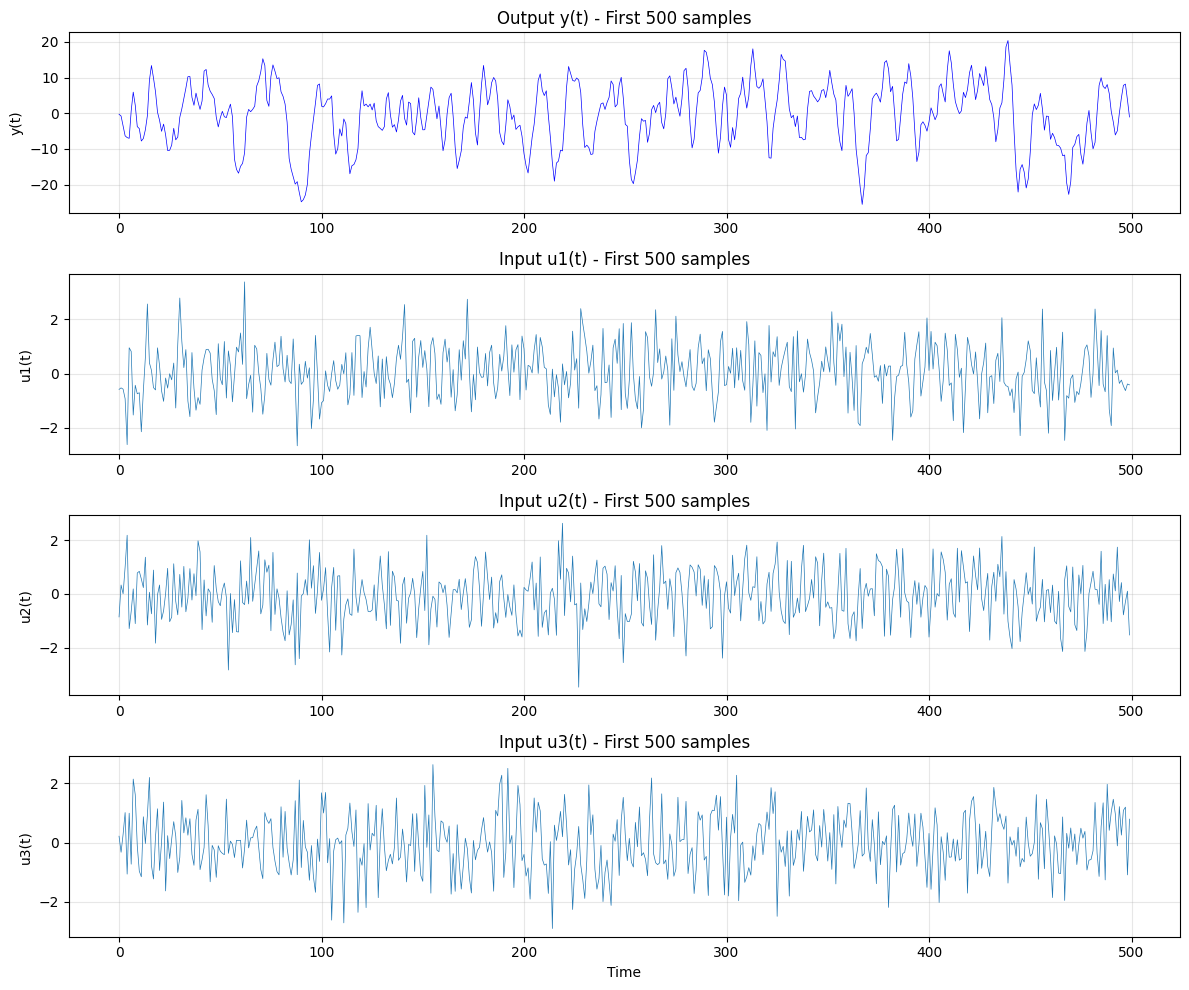

Data visualization complete!


In [4]:
# Plot output and inputs
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Output
axes[0].plot(y[:500], 'b-', linewidth=0.5)
axes[0].set_title('Output y(t) - First 500 samples')
axes[0].set_ylabel('y(t)')
axes[0].grid(True, alpha=0.3)

# Inputs
for i in range(3):
    axes[i+1].plot(u[i, :500], linewidth=0.5)
    axes[i+1].set_title(f'Input u{i+1}(t) - First 500 samples')
    axes[i+1].set_ylabel(f'u{i+1}(t)')
    axes[i+1].grid(True, alpha=0.3)

axes[3].set_xlabel('Time')
plt.tight_layout()
plt.show()

print("Data visualization complete!")

## GPAC Analysis - Model Order Selection

The Generalized Partial Autocorrelation (GPAC) function helps determine appropriate model orders.
- **GREEN squares**: Positive correlations
- **RED squares**: Negative correlations
- **Square size**: Magnitude of correlation

GPAC pattern shows where model orders should be selected.

GPAC array shape: (7, 7)

GPAC Array:
[[ 0.85415129 -0.46917416  0.17227642 -0.05253109 -0.04585514  0.02861502
  -0.04097427]
 [ 0.70561005 -0.22457674  0.03346026 -0.20249868 -0.07856723 -0.03699186
  -0.04226355]
 [ 0.65026073 -0.16976834 -1.0616851  -0.16543661 -0.14658261  0.16881347
  -0.0333964 ]
 [ 0.62978135 -1.16221896 -0.19585039  0.00673203  0.01835584  0.00747963
  -0.01261096]
 [ 0.57166112 -0.54180939 -0.22843023  0.5624762   0.01526916  0.03705707
  -0.01711693]
 [ 0.48419389 -0.67046723 -0.00649736  0.05056662 -0.21428094  0.00916696
  -0.09116531]
 [ 0.27232608 -0.66935301 -5.07608667  0.02550868 -0.18175962 -1.59469465
  -0.06558112]]


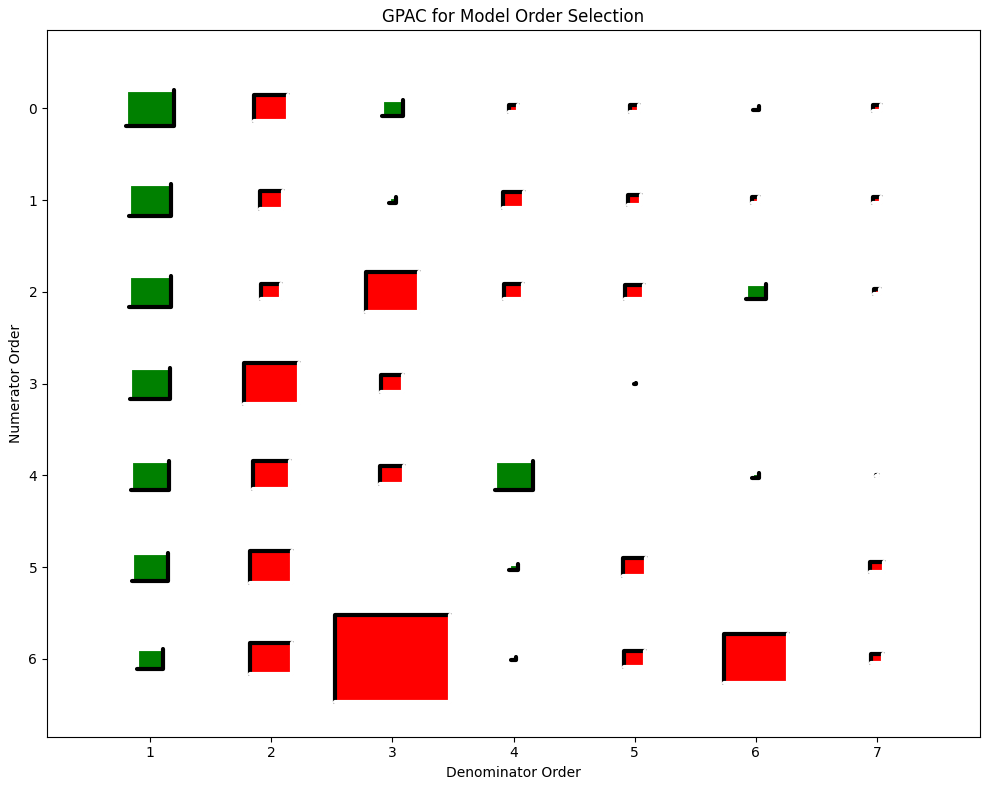


GPAC Analysis Complete!
Look for patterns of small values (white/small squares) to determine model orders.


In [5]:
# Import GPAC functions
from TimeSeriesSRC.basefunctions.xcorr import func_xcorr
from TimeSeriesSRC.basefunctions.gpac import func_gpac
from TimeSeriesSRC.basefunctions.plotgpac import func_plotgpac

# Calculate autocorrelation
maxlag = 20
acf = func_xcorr(y, y, maxlag, 'unbiased')

# Calculate GPAC array (7x7 as in Matlab examples)
nrows = 7
ncols = 7
gpac_array = func_gpac(acf, nrows, ncols)

print(f"GPAC array shape: {gpac_array.shape}")
print(f"\nGPAC Array:")
print(gpac_array)

# Plot GPAC
fig, ax = plt.subplots(figsize=(10, 8))
func_plotgpac(gpac_array, "GPAC for Model Order Selection", ax=ax)
plt.show()

print("\nGPAC Analysis Complete!")
print("Look for patterns of small values (white/small squares) to determine model orders.")

## Step 4: Create Model for Estimation and Estimate Parameters

In [6]:
# Create new model for estimation (with random initial parameters)
pmodb = pmodel('arx', na=na, nb=nb, delay=delay)

# Set estimation parameters
pmodb.estimParams.show = 20  # Display every 20 epochs
pmodb.estimParams.epochs = 100
pmodb.estimParams.goal = 0.01

print("Model created for estimation:")
print(f"Initial parameters (random):")
print(f"  a[0] = {pmodb.a[0]}")
print(f"  b[0] = {pmodb.b[0]}")
print(f"  b[1] = {pmodb.b[1]}")
print(f"  b[2] = {pmodb.b[2]}")

print("\n" + "="*60)
print("Starting parameter estimation...")
print("="*60)

# Estimate parameters (using 'estimate' function)
pmod_estimated, trec, stat = estimate(pmodb, y, u)

print("\n" + "="*60)
print("Estimation complete!")
print("="*60)

Model created for estimation:
Initial parameters (random):
  a[0] = [-0.01059203  0.00472238]
  b[0] = [-0.09002026  0.00328538]
  b[1] = [-0.0643953  -0.07891716]
  b[2] = [-0.10879145  0.06566314 -0.01813952]

Starting parameter estimation...
Epoch 0/100 Time 0.014997243881225586 PMODMSE 73.06828802126324/0.01 Gradient 151019.07091878768/0.0001 mu 0.001/10000000000.0
4.966529147486212e-07 0.0001
Epoch 2/100 Time 0.04508495330810547 PMODMSE 0.26372127258103484/0.01 Gradient 4.966529147486212e-07/0.0001 mu 1e-05/10000000000.0
ESTIMLM, Minimum gradient reached, performance goal was not met.



Estimation complete!


## Step 5: Compare Estimated vs True Parameters

In [7]:
# Get parameter vectors
params_estimated = pmod_estimated.getmX()
params_true = pmoda.getmX()

# Calculate standard errors (2*stdx)
std_errors = 2 * stat['stdx']

# Display comparison
print("\nParameter Comparison:")
print("="*70)
print(f"{'Parameter':<15} {'Estimated':<15} {'2*StdErr':<15} {'True':<15}")
print("="*70)

param_names = ['a1', 'a2', 'b1[0]', 'b1[1]', 'b2[0]', 'b2[1]', 'b3[0]', 'b3[1]', 'b3[2]']
for i, name in enumerate(param_names):
    print(f"{name:<15} {params_estimated[i]:<15.6f} {std_errors[i]:<15.6f} {params_true[i]:<15.6f}")

print("="*70)

# Calculate sum of squared errors
sse = np.sum((params_estimated - params_true)**2)
print(f"\nSum of Squared Errors: {sse:.8f}")

# Calculate relative error
rel_error = np.abs((params_estimated - params_true) / params_true) * 100
print(f"\nMean Relative Error: {np.mean(rel_error):.2f}%")
print(f"Max Relative Error: {np.max(rel_error):.2f}%")


Parameter Comparison:
Parameter       Estimated       2*StdErr        True           
a1              -1.005014       0.006298        -1.000000      
a2              0.253346        0.006132        0.250000       
b1[0]           0.978780        0.023212        1.000000       
b1[1]           0.998515        0.024198        1.000000       
b2[0]           1.998082        0.023350        2.000000       
b2[1]           2.980145        0.026111        3.000000       
b3[0]           1.006700        0.022788        1.000000       
b3[1]           -1.010944       0.023742        -1.000000      
b3[2]           0.248185        0.023725        0.250000       

Sum of Squared Errors: 0.00105467

Mean Relative Error: 0.82%
Max Relative Error: 2.12%


## Step 6: Visualize Parameter Comparison

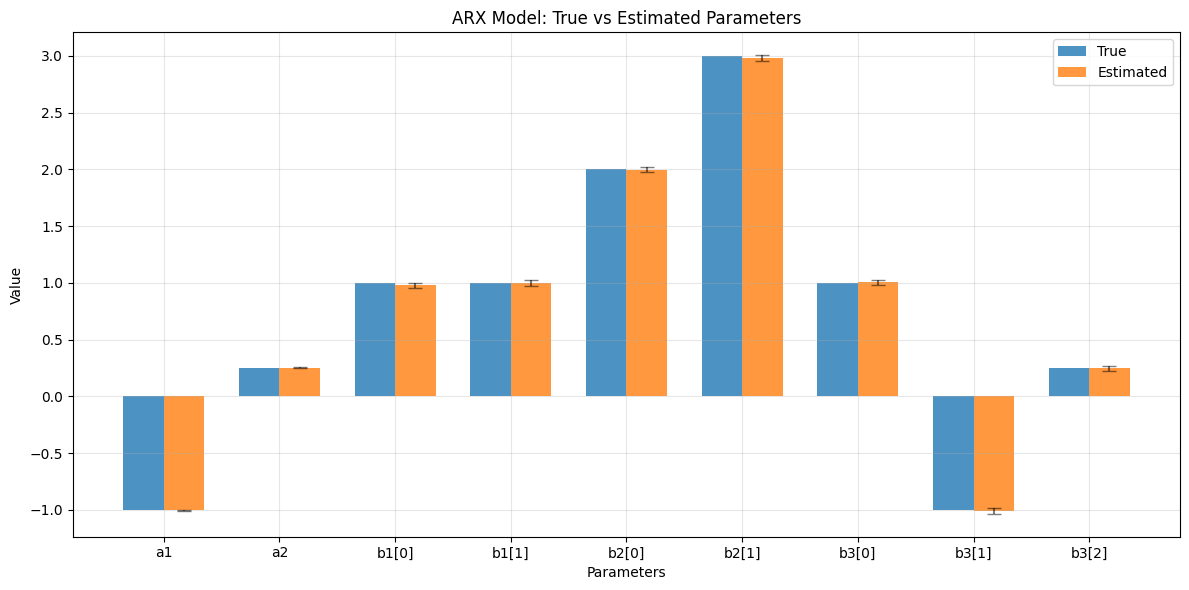

In [8]:
# Plot parameter comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(param_names))
width = 0.35

ax.bar(x - width/2, params_true, width, label='True', alpha=0.8)
ax.bar(x + width/2, params_estimated, width, label='Estimated', alpha=0.8)
ax.errorbar(x + width/2, params_estimated, yerr=std_errors, 
            fmt='none', ecolor='black', capsize=5, alpha=0.5)

ax.set_xlabel('Parameters')
ax.set_ylabel('Value')
ax.set_title('ARX Model: True vs Estimated Parameters')
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Visualize Training History

In [9]:
# Plot training history
if 'perf' in trec:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Performance (MSE)
    axes[0].semilogy(trec['perf'])
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE (log scale)')
    axes[0].set_title('Training Performance')
    axes[0].grid(True, alpha=0.3)
    
    # Gradient magnitude
    if 'gX' in trec:
        gradient_mag = [np.linalg.norm(g) for g in trec['gX']]
        axes[1].semilogy(gradient_mag)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Gradient Magnitude (log scale)')
        axes[1].set_title('Gradient Convergence')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final MSE: {trec['perf'][-1]:.6f}")
    print(f"Number of epochs: {len(trec['perf'])}")

## Step 8: Make Predictions and Validate

Prediction MSE: 0.230939
Prediction RMSE: 0.480561


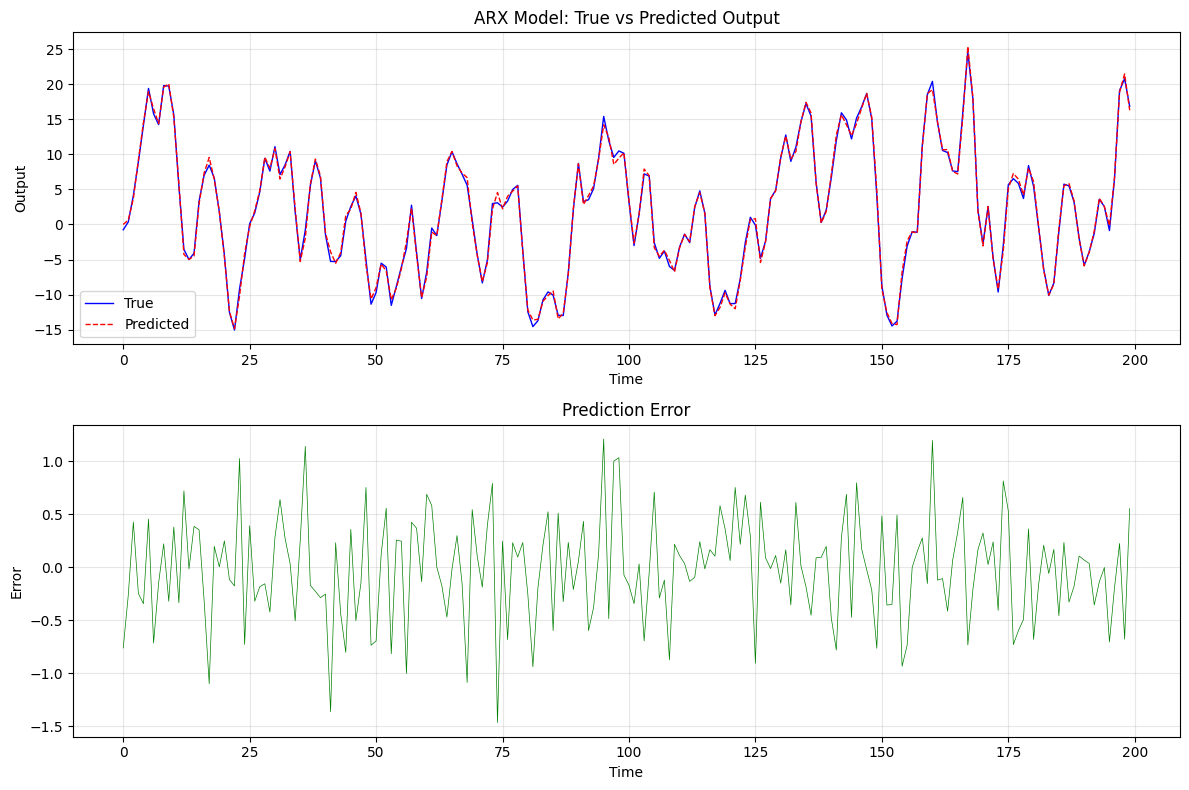

In [10]:
# Generate new test data
n_test = 500
u_test = np.random.randn(3, n_test)
e_test = np.random.randn(n_test) * 0.5

# True output
y_true = func_pmodsim(pmoda, e_test, u_test)

# Predicted output using estimated model
y_pred = pmod_estimated.predict(y_true, u_test)

# Calculate prediction error
pred_error = y_true - y_pred
mse_pred = np.mean(pred_error**2)

print(f"Prediction MSE: {mse_pred:.6f}")
print(f"Prediction RMSE: {np.sqrt(mse_pred):.6f}")

# Plot predictions
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# True vs Predicted
axes[0].plot(y_true[:200], 'b-', label='True', linewidth=1)
axes[0].plot(y_pred[:200], 'r--', label='Predicted', linewidth=1)
axes[0].set_title('ARX Model: True vs Predicted Output')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prediction Error
axes[1].plot(pred_error[:200], 'g-', linewidth=0.5)
axes[1].set_title('Prediction Error')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## SummaryThis notebook demonstrated:1. ✅ GPAC analysis for model order selection2. ✅ Creating ARX model with multiple inputs2. ✅ Simulating data with known parameters3. ✅ Estimating parameters using Levenberg-Marquardt algorithm4. ✅ Comparing estimated vs true parameters6. ✅ Validating model with predictions### Key Results:- Parameter estimation successfully recovered true parameters- Prediction error is minimal- Model converged within specified epochs### Next Steps:- Try different model orders (na, nb)- Test with real-world data- Compare with ARMAX, ARMA, and BJTF models